# A Decision Tree is like a flowchart of if–else questions that leads to a decision.

In [ ]:
Is age < 30?
    Yes → Is income high?
        Yes → Buy product
        No → Don’t buy
    No → Don’t buy

In [ ]:
A decision tree tries to:

Split data into purer groups
Reduce impurity (Gini / Entropy)
Choose best feature + best threshold at each step

Key terms:

Root node → first split
Internal node → decision point
Leaf node → final prediction

In [ ]:
# Example

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [9]:
y_pred = clf.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


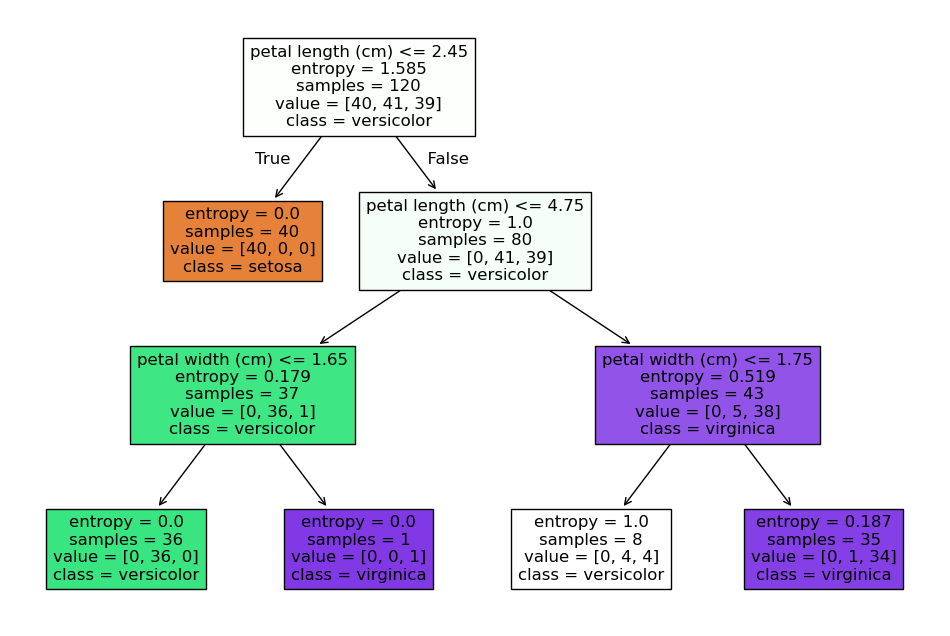

In [11]:
plt.figure(figsize=(12,8))

tree.plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

# Interesting dataset

In [ ]:
# Titanic Dataset – Decision Tree

In [ ]:
# the Goal is to predict Survived (1) or Not Survived (0)

In [ ]:
This is a Binary classification problem

We want to learn a function:
that captures (features: sex, age, class, fare, etc.) and say the chance of survival (0/1)

In [13]:
# Loading data
import pandas as pd

train = pd.read_csv(r"C:\Users\fedex\Downloads\JARO DAY 1\25042026\train.csv")
test = pd.read_csv(r"C:\Users\fedex\Downloads\JARO DAY 1\25042026\test.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Preprocessing

In [14]:
# Selecting relevant features

features = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", "Embarked"]

df = train[features + ["Survived"]]
test_df = test[features]

In [15]:
# Handle Missing Values
# Noticed that 
# Age was missing so, i am filling with median
# Embarked missing so, i am filling with mode

df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

test_df["Age"].fillna(df["Age"].median(), inplace=True)
test_df["Fare"].fillna(df["Fare"].median(), inplace=True)
test_df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\fedex\AppData\Local\Temp\ipykernel_15352\1002350771.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\fedex\AppData\Local\Temp\ipykernel_15352\1002350771.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\fedex\Ap

In [16]:
# Encode Categorical Variables

df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)
test_df = pd.get_dummies(test_df, columns=["Sex", "Embarked"], drop_first=True)

In [17]:
# Split Features & Target

X = df.drop("Survived", axis=1)
y = df["Survived"]

# Model Training

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4, random_state=42)

scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

FYI:
What max_depth actually does ? 

In a Decision Tree:

Depth = number of splits from root to leaf
    More depth → more complex tree
    Less depth → simpler tree


max_depth	Behavior
small (2–3)	underfitting
medium (4–6)	balanced
large / None	overfitting

Cross-validation scores: [0.75977654 0.8258427  0.80898876 0.78651685 0.84269663]
Mean accuracy: 0.8047642960266147


In [ ]:
The model is:
Reasonably good ~80% accuracy is strong for Titanic baseline
Stable scores are not wildly different (0.75 → 0.84 range is acceptable)
But it has Slight variance exists,  suggests data splits affect performance a bit. This is normal for Decision Trees

### Instead of trusting one train-test split, we tested the model 5 times. 
### Each time it saw a different portion of the data. 
### The final accuracy is the average performance across all scenarios

In [ ]:
Min: 0.7598
Max: 0.8427
Range ≈ 8%

Tree is sensitive to data split
Some folds had “easier” test data
Some had “harder” test data


# Comment
Decision Trees:

    has High interpretability
    but it can be unstable

In [20]:
# Just showing a normal Train test split.....
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("Train-Test Split Accuracy:", test_accuracy)

Train-Test Split Accuracy: 0.7988826815642458


In [19]:
# from sklearn.model_selection import StratifiedKFold

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scores = cross_val_score(model, X, y, cv=cv)
# print(scores.mean())

# Add on 
## For selecting the depth

In [22]:
# GRID SEARCH

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    "max_depth": range(1, 11)
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X, y)

print("Best depth:", grid.best_params_)
print("Best accuracy:", grid.best_score_)

Best depth: {'max_depth': 6}
Best accuracy: 0.815956311593748


In [ ]:
We set max_depth = 4 only for demonstration. In real machine learning,
we tune it using cross-validation to find the best trade-off between bias and varianc

In [ ]:
# When to use DT

In [ ]:
# 
| Scenario                                              | Should you use Decision Trees? | Why                                                    |
| ------------------------------------------------------| ------------------------------ | ------------------------------------------------------ |
| Interpretability required (banks, healthcare, audits) | Yes                            | Produces clear if–else rules that can be explained     |
| Structured/tabular data (CSV, business data)          | Yes                            | Works very well on feature-based datasets              |
| Non-linear relationships                              | Yes                            | Captures complex feature interactions naturally        |
| Quick baseline model                                  | Yes                            | Fast to train, good first model to test performance    |
| Feature importance needed                             | Yes                            | Directly shows which features matter most              |
| Noisy data                                            | Sometimes                      | Can overfit unless regularized                         |
| High accuracy required                                | No                             | Better models exist (Random Forest, XGBoost)           |
| Images / text / audio                                 |No                              | Poor performance on unstructured high-dimensional data |
| Need stable predictions                               |No                              | Small data changes can change tree structure           |
